In [13]:
import torch.autograd
from diffusers import StableDiffusionPipeline

torch.autograd.set_grad_enabled(False)

pipe = StableDiffusionPipeline.from_pretrained('../models/sd-2/main/sdsf-flowmatch-largeres-60k-bs1k_1e5cos_b1_0.6_b2_0.96-8k_m2x/', low_cpu_mem_usage=False)
pipe = pipe.to('mps')


Loading pipeline components...:  40%|████      | 2/5 [00:00<00:00, 13.74it/s]Some weights of UNet2DConditionModel were not initialized from the model checkpoint at ../models/sd-2/main/sdsf-flowmatch-largeres-60k-bs1k_1e5cos_b1_0.6_b2_0.96-8k_m2x/unet and are newly initialized: ['up_blocks.1.attentions.0.transformer_blocks.0.attn2.norm_k.weight', 'up_blocks.3.attentions.2.transformer_blocks.0.attn1.norm_k.weight', 'up_blocks.1.attentions.2.transformer_blocks.0.attn1.norm_q.weight', 'up_blocks.3.attentions.1.transformer_blocks.0.attn2.norm_q.weight', 'down_blocks.1.attentions.0.transformer_blocks.0.attn2.norm_k.weight', 'down_blocks.2.attentions.0.transformer_blocks.0.attn1.norm_q.weight', 'up_blocks.1.attentions.2.transformer_blocks.0.attn2.norm_q.weight', 'down_blocks.1.attentions.1.transformer_blocks.0.attn1.norm_q.weight', 'up_blocks.2.attentions.2.transformer_blocks.0.attn2.norm_k.weight', 'down_blocks.2.attentions.1.transformer_blocks.0.attn1.norm_q.weight', 'up_blocks.3.attentions

In [14]:
from diffusers import FlowMatchEulerDiscreteScheduler

scheduler = FlowMatchEulerDiscreteScheduler.from_config(pipe.scheduler.config)
prev_set_timesteps = FlowMatchEulerDiscreteScheduler.set_timesteps
def set_timesteps(self, *args, **kwargs):
    prev_set_timesteps(self, *args, **kwargs)
    self.timesteps = self.timesteps.long()
scheduler.set_timesteps = set_timesteps.__get__(scheduler, FlowMatchEulerDiscreteScheduler)
scheduler.init_noise_sigma = 1
scheduler.scale_model_input = lambda x, t: x

pipe: StableDiffusionPipeline
pipe.scheduler = scheduler


The config attributes {'skip_prk_steps': True} were passed to FlowMatchEulerDiscreteScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


In [15]:
pipe = pipe.to('mps')#, dtype=torch.float16)

In [16]:
def nan_pre_hook(module, input):
    tensors = input
    if type(tensors) is torch.Tensor:
        tensors = [tensors]
    for t in tensors:
      if type(t) is not torch.Tensor:
          continue
      if torch.isnan(t).any():
          print(f"NaN detected entering {module.__class__.__name__}")


def nan_post_hook(module, input, output):
    tensors = output
    if type(tensors) is torch.Tensor:
        tensors = [tensors]
    for t in tensors:
      if type(t) is not torch.Tensor:
          continue
      if torch.isnan(t).any():
          print(f"NaN detected after {module.__class__.__name__}")

# Register hooks on suspect layers
for name, module in pipe.unet.named_modules():
    #if isinstance(module, (torch.nn.GroupNorm, torch.nn.LayerNorm)):
    module: torch.nn.Module
    module.register_forward_hook(nan_post_hook)
    module.register_forward_pre_hook(nan_pre_hook)

# Keep all Linear layers in attention blocks as float32
#for name, module in pipe.unet.named_modules():
#    if isinstance(module, torch.nn.Linear) and 'attn' in name:
#        module.float()

100%|██████████| 25/25 [01:13<00:00,  2.95s/it]


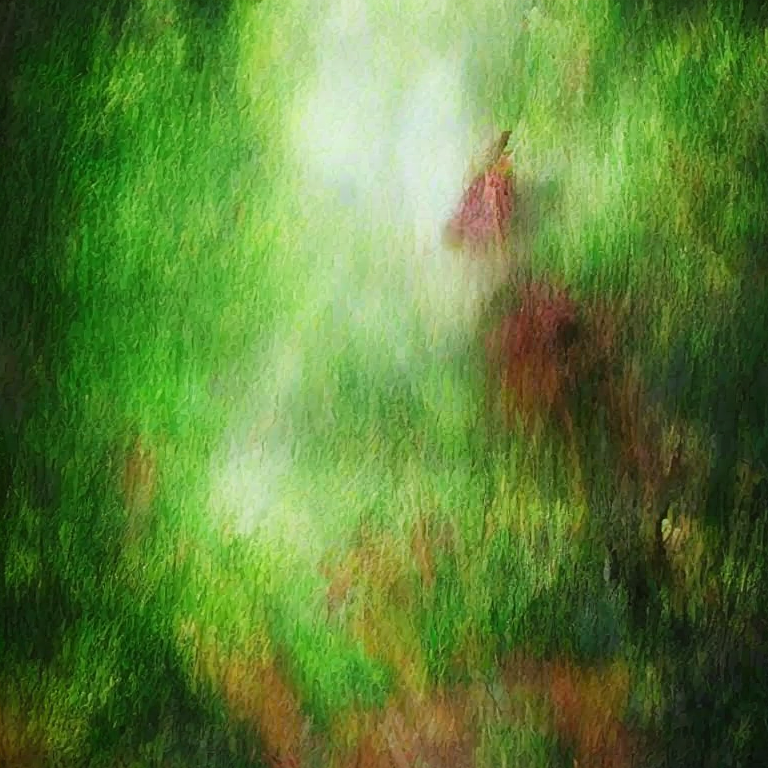

In [18]:
generator = torch.Generator(device='cpu').manual_seed(1)
#pipe.set_progress_bar_config(disable=True)
images = pipe(prompt="a cat in the forest", negative_prompt=None, height=768, width=768, num_inference_steps=25, guidance_scale=4)
display(images.images[0])

In [ ]:
generator = torch.Generator(device='cpu').manual_seed(2)
images = pipe(prompt=prompt, negative_prompt=None, height=480, width=1280, num_inference_steps=60, guidance_scale=8)
display(images.images[0])

In [ ]:
prompt = "epic sci-fi blockbuster film frame, dramatic low angle shot, astronaut in reflective helmet standing on alien planet surface, twin moons in purple sky, volumetric lighting cutting through atmospheric haze, anamorphic lens flares, rich contrast, IMAX quality"
negative_prompt = "grainy, low quality"
generator = torch.Generator(device='cpu').manual_seed(2)
images = pipe(prompt=prompt, negative_prompt=negative_prompt, height=1024, width=640, num_inference_steps=30, guidance_scale=4)
display(images.images[0])

In [ ]:
images.images[0].save('/tmp/epic-scifi-2.jpg', quality=95)

In [ ]:
generator = torch.Generator(device='cpu').manual_seed(2)
images = pipe(prompt=prompt, negative_prompt=None, height=480, width=1280, num_inference_steps=60, guidance_scale=2)
display(images.images[0])

In [ ]:
generator = torch.Generator(device='cpu').manual_seed(1)
images = pipe(prompt="a fish", negative_prompt=None, height=512, width=512, num_inference_steps=60, guidance_scale=8)
display(images.images[0])
